# Speed Benchmark: Entropy Pruning vs CropR vs ToMe vs EViT vs DynamicViT vs MCTF vs Baseline

Confronto sistematico della velocità di inferenza:

| Metodo | Descrizione | Training richiesto |
|---|---|---|
| **Baseline** | UNI LoRA fine-tuned, nessun pruning | — |
| **Entropy Pruning** | Forecaster + pruning al layer 2, fine-tuning pruning-aware | Sì |
| **CropR** | Token reduction progressiva via cross-attention | Sì |
| **ToMe** | Token merging bipartite matching (parameter-free) | No |
| **EViT** | Top-K su CLS attention, fuse_token | Sì (fine-tuning) |
| **DynamicViT** | PredictorLG Gumbel-Softmax, 3 stadi | Sì (solo predictor) |
| **MCTF** | Multi-criteria bipartite fusion (sim+info+size), one-step-ahead | **No** |

**Metrica primaria:** Throughput (img/s) a batch=32, misurato con `torch.cuda.Event` su input pre-allocato su GPU.  
**Metrica secondaria:** Latenza (ms/img) a batch=1.  

**Nota:** MCTF è parameter-free e può essere testato direttamente senza training.

## 0 · Imports

In [1]:
import copy, gc, json, time, sys
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import timm
from peft import LoraConfig
from peft.tuners.lora import LoraModel
from sklearn.metrics import f1_score
from tome.patch import timm as tome_patch_timm
from fvcore.nn import FlopCountAnalysis

sys.path.append(".")
from src.dataset import HistologicalImageDataset
from src.vision_transformer_copr import VisionTransformer as CroprVisionTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {device} | timm: {timm.__version__}")

Device: cuda | timm: 1.0.25


/home/oem/miniconda3/envs/trident/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 1 · Configurazione

In [2]:
DATASET_NAME = "NCT-CRC-HE"
CKPT_BASE    = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}")

CFG = dict(
    # dataset
    data_dir        = f"/data/{DATASET_NAME}",
    img_size        = 224,
    patch_size      = 16,
    # evaluation (accuracy)
    eval_batch_size = 32,
    eval_workers    = 4,
    far_threshold   = 1e-4,
    # throughput benchmark (batch=32)
    thr_batch_size  = 32,
    thr_warmup      = 30,
    thr_iters       = 150,
    thr_repeats     = 4,
    # latency benchmark (batch=1)
    lat_warmup      = 50,
    lat_iters       = 300,
    lat_repeats     = 5,
    # pruning
    prune_layer     = 2,
    keep_ratios     = [0.1, 0.2, 0.3, 0.5],
    # ToMe
    tome_r_values   = [0, 4, 8, 16, 24],
    # checkpoints
    ckpt_classifier = CKPT_BASE / "uni_finetuned"    / "best_model.pt",
    ckpt_forecaster = CKPT_BASE / "forecaster"       / "forecaster_src02_tgt23.pt",
    ckpt_pruned_ft  = CKPT_BASE / "pruned_finetuned" / "best_prune_layer2_keep10.pt",
    ckpt_cropr      = CKPT_BASE / "uni_cropr"        / "best_model.pt",
    # output
    results_dir     = Path(f"results/{DATASET_NAME}/speed_comparison"),
)
CFG["results_dir"].mkdir(parents=True, exist_ok=True)
print(f"Dataset: {DATASET_NAME}")
print(f"Checkpoints: {CKPT_BASE}")

Dataset: NCT-CRC-HE
Checkpoints: /data/checkpoints-Attention-Pruning/NCT-CRC-HE


## 2 · Dataset

In [4]:
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
test_ds     = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=eval_tf)
test_loader = DataLoader(
    test_ds, batch_size=CFG["eval_batch_size"], shuffle=False,
    num_workers=CFG["eval_workers"], pin_memory=True, persistent_workers=True,
)
CLASS_NAMES = test_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Test: {len(test_ds)} campioni | {N_CLASSES} classi: {CLASS_NAMES}")

Loading from /data/NCT-CRC-HE/test...
Loaded 7180 samples, 9 classes
Class distribution:
  ADI: 1338 (18.6%)
  BACK: 847 (11.8%)
  DEB: 339 (4.7%)
  LYM: 634 (8.8%)
  MUC: 1035 (14.4%)
  MUS: 592 (8.2%)
  NORM: 741 (10.3%)
  STR: 421 (5.9%)
  TUM: 1233 (17.2%)
Test: 7180 campioni | 9 classi: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']


## 3 · Architetture

In [5]:
# ── Base LoRA classifier ───────────────────────────────────────────────────
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True, num_classes=0,
        )
        lora_cfg = LoraConfig(
            r=8, lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],
            lora_dropout=0.1, bias="none",
        )
        self.backbone = LoraModel(backbone, lora_cfg, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


# ── Attention Forecaster ───────────────────────────────────────────────────
class AttentionForecaster(nn.Module):
    def __init__(self, embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, hidden)
        self.cls_query   = nn.Parameter(torch.randn(1, 1, hidden) * 0.02)
        self.self_attn   = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden, nhead=n_heads, dim_feedforward=hidden * 2,
                dropout=dropout, batch_first=True, norm_first=True,
            ) for _ in range(n_layers)
        ])
        self.cross_attn  = nn.ModuleList([
            nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_layers)
        ])
        self.cross_norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.norm        = nn.LayerNorm(hidden)
        self.score_head  = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x)
        for sa in self.self_attn:
            x = sa(x)
        cls = self.cls_query.expand(B, -1, -1)
        for ca, norm in zip(self.cross_attn, self.cross_norms):
            cls_out, _ = ca(cls, x, x)
            cls = norm(cls + cls_out)
        x_norm  = self.norm(x)
        cls_exp = cls.expand(-1, N, -1)
        return self.score_head(torch.cat([x_norm, cls_exp], dim=-1)).squeeze(-1).softmax(-1)


# ── Integrated Pruned Classifier ───────────────────────────────────────────
# FIX rispetto a fair_comparison_pruning_v2:
#   blk.norm1(x) veniva calcolata DUE VOLTE nel ramo forecaster
#   (una volta esplicitamente, una volta dentro blk(x)).
#   Qui il blocco è eseguito manualmente in tutti i rami: norm1 calcolata UNA sola volta.
class IntegratedPrunedClassifier(nn.Module):
    """
    UNILoRAClassifier con token pruning integrato nel forward.
    Nessun hook Python: zero overhead di attach/detach a ogni forward.
    """
    def __init__(self, base_model, keep_ratio, prune_layer, forecaster=None):
        super().__init__()
        self.backbone    = base_model.backbone
        self.head        = base_model.head
        self.keep_ratio  = keep_ratio
        self.prune_layer = prune_layer
        self.forecaster  = forecaster

    def forward(self, x):
        vit = self.backbone.model
        B   = x.shape[0]

        # ── Preamble ViT
        x = vit.patch_embed(x)
        x = vit._pos_embed(x)
        x = vit.patch_drop(x)
        x = vit.norm_pre(x)

        # ── Layer prima del pruning
        for i in range(self.prune_layer):
            x = vit.blocks[i](x)

        # ── Blocco di pruning: esecuzione manuale per calcolare norm1 UNA SOLA VOLTA
        blk  = vit.blocks[self.prune_layer]
        N, C = x.shape[1], x.shape[2]

        x_norm1 = blk.norm1(x)  # ← calcolata ESATTAMENTE UNA VOLTA

        if self.forecaster is not None:
            # Forecaster usa x_norm1 (patch tokens) già calcolato
            scores = self.forecaster(x_norm1[:, 1:])
        else:
            # Fallback: CLS attention score al layer corrente
            qkv_s = blk.attn.qkv(x_norm1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2, 0, 3, 1, 4)
            q_s, k_s, _ = qkv_s.unbind(0)
            q_s, k_s = blk.attn.q_norm(q_s), blk.attn.k_norm(k_s)
            attn_s  = (q_s @ k_s.transpose(-2, -1) * blk.attn.scale).softmax(-1)
            scores  = attn_s[:, :, 0, 1:].mean(dim=1)

        # Completa il blocco usando x_norm1 già disponibile (no secondo norm1)
        qkv = blk.attn.qkv(x_norm1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn    = (q @ k.transpose(-2, -1) * blk.attn.scale).softmax(-1)
        attn_out = (blk.attn.attn_drop(attn) @ v).transpose(1, 2).reshape(B, N, C)
        attn_out = blk.attn.proj_drop(blk.attn.proj(attn_out))
        if hasattr(blk, "ls1"):
            x = x + blk.drop_path1(blk.ls1(attn_out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(attn_out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))

        # ── Token selection (gather vettorizzato)
        k_keep  = max(1, int((N - 1) * self.keep_ratio))
        topk_idx = scores.topk(k_keep, dim=-1).indices
        cls_tok  = x[:, :1, :]
        patches  = x[:, 1:, :]
        kept     = torch.gather(patches, 1, topk_idx.unsqueeze(-1).expand(-1, -1, C))
        x        = torch.cat([cls_tok, kept], dim=1)

        # ── Layer dopo il pruning (sequenza ridotta)
        for i in range(self.prune_layer + 1, len(vit.blocks)):
            x = vit.blocks[i](x)

        x = vit.norm(x)
        x = x[:, 0]  # CLS token (global_pool="token")
        return self.head(x)


# ── CropR ──────────────────────────────────────────────────────────────────
class UNICroprClassifier(CroprVisionTransformer):
    def __init__(self, cropr_cfg, init_values=1e-5, **kwargs):
        super().__init__(cropr_cfg, **kwargs)
        dpr = [x.item() for x in torch.linspace(0, kwargs["drop_path_rate"], len(self.blocks))]
        if cropr_cfg["use_cropr"]:
            dpr[-1] = 0.0
        for i in range(len(self.blocks)):
            self.blocks[i] = timm.models.vision_transformer.Block(
                dim=self.embed_dim, num_heads=kwargs["num_heads"],
                qkv_bias=True, init_values=init_values,
                drop_path=dpr[i], norm_layer=partial(nn.LayerNorm, eps=1e-6),
            )

def build_cropr_model(n_classes):
    cropr_cfg = dict(
        use_cropr=True, pruning_rate=8, llf=False, num_queries=1,
        num_heads=1, pre_attn_norm=False, q_proj=False, k_proj=False,
        v_proj=False, mlp=True, mlp_ratio=4.0, training=True,
    )
    return UNICroprClassifier(
        cropr_cfg, init_values=1e-5,
        num_classes=n_classes, img_size=CFG["img_size"],
        patch_size=CFG["patch_size"], embed_dim=1024, depth=24,
        num_heads=16, mlp_ratio=4.0, drop_path_rate=0.2,
        global_pool="avg", class_token=True,
    )

print("Architetture definite.")

Architetture definite.


## 4 · Funzioni di benchmark

In [6]:
def load_ckpt(model, path, strict=False):
    state = torch.load(Path(path), map_location="cpu")
    if "state_dict" in state:
        state = state["state_dict"]
    state = {k.replace("module.", ""): v for k, v in state.items()}
    miss, unex = model.load_state_dict(state, strict=strict)
    if miss:  print(f"  [WARN] {len(miss)} missing keys")
    if unex:  print(f"  [WARN] {len(unex)} unexpected keys")
    return model

def freeze(model):
    model.eval()
    for p in model.parameters(): p.requires_grad_(False)
    return model

def unload(*models):
    for m in models:
        if m is not None: m.cpu()
    torch.cuda.empty_cache(); gc.collect()


@torch.no_grad()
def measure_throughput(model):
    """
    Throughput in img/s a batch_size=CFG['thr_batch_size'].
    Metrica primaria: mostra il vantaggio reale del pruning su GPU.
    """
    model.eval()
    B    = CFG["thr_batch_size"]
    x    = torch.randn(B, 3, CFG["img_size"], CFG["img_size"], device=device)
    aoc  = device.type == "cuda"
    n_w, n_i, n_r = CFG["thr_warmup"], CFG["thr_iters"], CFG["thr_repeats"]

    for _ in range(n_w):
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
            _ = model(x)

    thrputs = []
    for _ in range(n_r):
        if device.type == "cuda":
            torch.cuda.synchronize()
            s = torch.cuda.Event(enable_timing=True)
            e = torch.cuda.Event(enable_timing=True)
            s.record()
            for _ in range(n_i):
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
                    _ = model(x)
            e.record(); torch.cuda.synchronize()
            elapsed_s = s.elapsed_time(e) / 1000.0
        else:
            t0 = time.perf_counter()
            for _ in range(n_i): _ = model(x)
            elapsed_s = time.perf_counter() - t0
        thrputs.append(n_i * B / elapsed_s)

    return float(np.mean(thrputs)), float(np.std(thrputs))


@torch.no_grad()
def measure_latency_ms(model):
    """
    Latenza single-image in ms (batch=1).
    A token ridotti può apparire più lenta per l'overhead fisso dei kernel CUDA.
    """
    model.eval()
    x    = torch.randn(1, 3, CFG["img_size"], CFG["img_size"], device=device)
    aoc  = device.type == "cuda"
    n_w, n_i, n_r = CFG["lat_warmup"], CFG["lat_iters"], CFG["lat_repeats"]

    for _ in range(n_w):
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
            _ = model(x)

    tms = []
    for _ in range(n_r):
        if device.type == "cuda":
            torch.cuda.synchronize()
            s = torch.cuda.Event(enable_timing=True)
            e = torch.cuda.Event(enable_timing=True)
            s.record()
            for _ in range(n_i):
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
                    _ = model(x)
            e.record(); torch.cuda.synchronize()
            tms.append(s.elapsed_time(e) / n_i)
        else:
            t0 = time.perf_counter()
            for _ in range(n_i): _ = model(x)
            tms.append((time.perf_counter() - t0) * 1000.0 / n_i)

    return float(np.mean(tms)), float(np.std(tms))


def measure_gflops(model):
    model.eval()
    dummy = torch.randn(1, 3, CFG["img_size"], CFG["img_size"], device=device)
    try:
        fa = FlopCountAnalysis(model, dummy)
        fa.unsupported_ops_warnings(False); fa.uncalled_modules_warnings(False)
        return fa.total() / 1e9
    except Exception as ex:
        print(f"[WARN] GFLOPs non calcolabili: {ex}")
        return None


@torch.no_grad()
def run_inference(model, loader):
    """Inferenza batched su tutto il test set per metriche di qualità."""
    model.eval()
    preds, labels_all, scores_all = [], [], []
    aoc = device.type == "cuda"
    for imgs, lbls in tqdm(loader, leave=False, desc="Eval"):
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
            logits = model(imgs.to(device, non_blocking=True))
        probs = logits.float().softmax(-1).cpu()
        preds.extend(probs.argmax(-1).tolist())
        labels_all.extend(lbls.tolist())
        scores_all.extend(probs.max(-1).values.tolist())
    return np.array(preds), np.array(labels_all), np.array(scores_all)


def compute_metrics(preds, labels, scores, far_threshold=1e-4):
    incorrect = ~(preds == labels)
    if incorrect.sum() == 0:
        tar = 1.0
    else:
        n_far = max(1, int(np.ceil(incorrect.sum() * far_threshold)))
        thr   = np.sort(scores[incorrect])[::-1][min(n_far - 1, incorrect.sum() - 1)]
        tar   = float((scores[preds == labels] >= thr).mean())
    return {
        "accuracy":   float((preds == labels).mean()),
        "f1_macro":   float(f1_score(labels, preds, average="macro", zero_division=0)),
        "tar_at_far": tar,
    }


def benchmark(model, tag, record_quality=True):
    """Esegue tutto il benchmark su un modello e restituisce un dict."""
    print(f"  [{tag}] throughput... ", end="", flush=True)
    thr, thr_std = measure_throughput(model)
    print(f"{thr:.0f} img/s  |  latency... ", end="", flush=True)
    lat, lat_std = measure_latency_ms(model)
    print(f"{lat:.2f} ms  |  GFLOPs... ", end="", flush=True)
    gflops = measure_gflops(model)
    print(f"{gflops:.1f}" if gflops else "N/A")

    metrics = {}
    if record_quality:
        print(f"  [{tag}] accuracy... ", end="", flush=True)
        preds, labels, scores = run_inference(model, test_loader)
        metrics = compute_metrics(preds, labels, scores, CFG["far_threshold"])
        print(f"F1={metrics['f1_macro']:.4f}  TAR={metrics['tar_at_far']:.4f}")

    return dict(
        throughput=thr, throughput_std=thr_std,
        latency_ms=lat, latency_std=lat_std,
        gflops=gflops,
        **metrics,
    )

print("Funzioni di benchmark pronte.")

Funzioni di benchmark pronte.


## 5 · Baseline (nessun pruning)

In [6]:
all_records = []

print("=== Baseline ===")
clf_base = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                             CFG["ckpt_classifier"], strict=False))

res_base = benchmark(clf_base, "Baseline")
baseline_throughput = res_base["throughput"]

all_records.append({"method": "Baseline", "variant": "—",
                    "keep_ratio": None, "speedup": 1.0, **res_base})
unload(clf_base)
print(f"Baseline throughput: {baseline_throughput:.0f} img/s  (riferimento = 1.00×)")

=== Baseline ===
  [Baseline] throughput... 266 img/s  |  latency... 23.34 ms  |  GFLOPs... 60.3
  [Baseline] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7880  TAR=0.0000
Baseline throughput: 266 img/s  (riferimento = 1.00×)


## 6 · Entropy Pruning (Forecaster + Fine-tuning)

Il classificatore è fine-tuned con pruning al layer 2 (checkpoint `best_prune_layer2_keep10.pt`).  
Il forecaster predice i punteggi di importanza dei patch token dalla rappresentazione al layer 2,
senza dover eseguire tutti i 24 layer.

Viene testato a diversi `keep_ratio` per mostrare il trade-off accuratezza/velocità.

In [7]:
print("=== Entropy Pruning (Forecaster + FT) ===")

# Carica base model con checkpoint pruning-aware
clf_ft = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                           CFG["ckpt_pruned_ft"], strict=False))

# Carica forecaster
forecaster = freeze(load_ckpt(AttentionForecaster().to(device),
                               CFG["ckpt_forecaster"], strict=True))

pruning_records = []
for kr in CFG["keep_ratios"]:
    tag = f"Pruning keep={int(kr*100)}%"
    print(f"\n  keep_ratio = {kr:.0%} ({max(1, int(196*kr))} token mantenuti su 196)")

    model_p = IntegratedPrunedClassifier(
        clf_ft,
        keep_ratio=kr,
        prune_layer=CFG["prune_layer"],
        forecaster=forecaster,
    ).to(device)
    freeze(model_p)

    res = benchmark(model_p, tag)
    row = {
        "method":   "Entropy Pruning",
        "variant":  f"{int(kr*100)}% token",
        "keep_ratio": kr,
        "speedup":  res["throughput"] / baseline_throughput,
        **res,
    }
    pruning_records.append(row)
    all_records.append(row)
    print(f"    Speedup: {row['speedup']:.2f}×  |  F1: {res.get('f1_macro', float('nan')):.4f}  |"
          f"  TAR@FAR: {res.get('tar_at_far', float('nan')):.4f}")

    del model_p
    torch.cuda.empty_cache()

unload(clf_ft, forecaster)
print("\nEntropy Pruning completato e modelli scaricati.")

=== Entropy Pruning (Forecaster + FT) ===
  [WARN] 45 unexpected keys

  keep_ratio = 10% (19 token mantenuti su 196)
  [Pruning keep=10%] throughput... 933 img/s  |  latency... 26.64 ms  |  GFLOPs... 13.3
  [Pruning keep=10%] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.8646  TAR=0.0011
    Speedup: 3.51×  |  F1: 0.8646  |  TAR@FAR: 0.0011

  keep_ratio = 20% (39 token mantenuti su 196)
  [Pruning keep=20%] throughput... 722 img/s  |  latency... 26.66 ms  |  GFLOPs... 18.7
  [Pruning keep=20%] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.8860  TAR=0.0006
    Speedup: 2.72×  |  F1: 0.8860  |  TAR@FAR: 0.0006

  keep_ratio = 30% (58 token mantenuti su 196)
  [Pruning keep=30%] throughput... 574 img/s  |  latency... 25.90 ms  |  GFLOPs... 23.7
  [Pruning keep=30%] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.8930  TAR=0.0003
    Speedup: 2.16×  |  F1: 0.8930  |  TAR@FAR: 0.0003

  keep_ratio = 50% (98 token mantenuti su 196)
  [Pruning keep=50%] throughput... 425 img/s  |  latency... 27.30 ms  |  GFLOPs... 34.4
  [Pruning keep=50%] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.8963  TAR=0.0126
    Speedup: 1.60×  |  F1: 0.8963  |  TAR@FAR: 0.0126

Entropy Pruning completato e modelli scaricati.


## 7 · CropR

In [8]:
print("=== CropR ===")
clf_cropr = freeze(load_ckpt(build_cropr_model(N_CLASSES).to(device),
                              CFG["ckpt_cropr"], strict=False))

res_cropr = benchmark(clf_cropr, "CropR")
all_records.append({
    "method":  "CropR", "variant": "—", "keep_ratio": None,
    "speedup": res_cropr["throughput"] / baseline_throughput,
    **res_cropr,
})
print(f"Speedup CropR: {all_records[-1]['speedup']:.2f}×")
unload(clf_cropr)
print("CropR scaricato.")

=== CropR ===
Cropr schedule (tokens remaining): [188, 180, 172, 164, 156, 148, 140, 132, 124, 116, 108, 100, 92, 84, 76, 68, 60, 52, 44, 36, 28, 20, 12]
  [CropR] throughput... 628 img/s  |  latency... 15.83 ms  |  GFLOPs... 31.6
  [CropR] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.8126  TAR=0.0002
Speedup CropR: 2.36×
CropR scaricato.


## 8 · ToMe (Token Merging)

`r` = numero di token mergati per blocco. Con 24 blocchi e r=8 si riducono 192 token totali.

In [9]:
print("=== ToMe ===")

# Carica il classificatore base (senza pruning-ft) per ToMe
clf_tome_base = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                                  CFG["ckpt_classifier"], strict=False))

tome_records = []
for r in CFG["tome_r_values"]:
    n_patches   = (CFG["img_size"] // CFG["patch_size"]) ** 2
    tokens_left = max(n_patches - r * 24, 1)
    keep_approx = tokens_left / n_patches
    tag = f"ToMe r={r}" if r > 0 else "ToMe r=0 (baseline)"
    print(f"\n  r={r}  (token residui ≈ {tokens_left}, keep ≈ {keep_approx:.0%})")

    model_r = copy.deepcopy(clf_tome_base).to(device)
    if r > 0:
        # ToMe va applicato al ViT interno del wrapper LoRA
        tome_patch_timm(model_r.backbone.model, trace_source=False, prop_attn=True)
        model_r.backbone.model.r = r
    freeze(model_r)

    res = benchmark(model_r, tag)
    row = {
        "method":   "ToMe",
        "variant":  f"r={r}",
        "keep_ratio": keep_approx,
        "speedup":  res["throughput"] / baseline_throughput,
        **res,
    }
    tome_records.append(row)
    all_records.append(row)
    print(f"    Speedup: {row['speedup']:.2f}×  |  F1: {res.get('f1_macro', float('nan')):.4f}")

    del model_r
    torch.cuda.empty_cache()

unload(clf_tome_base)
print("\nToMe completato e modelli scaricati.")

=== ToMe ===

  r=0  (token residui ≈ 196, keep ≈ 100%)
  [ToMe r=0 (baseline)] throughput... 263 img/s  |  latency... 24.58 ms  |  GFLOPs... 60.3
  [ToMe r=0 (baseline)] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7880  TAR=0.0000
    Speedup: 0.99×  |  F1: 0.7880

  r=4  (token residui ≈ 100, keep ≈ 51%)
  [ToMe r=4] throughput... 269 img/s  |  latency... 38.21 ms  |  GFLOPs... 46.6
  [ToMe r=4] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7802  TAR=0.0010
    Speedup: 1.01×  |  F1: 0.7802

  r=8  (token residui ≈ 4, keep ≈ 2%)
  [ToMe r=8] throughput... 386 img/s  |  latency... 38.59 ms  |  GFLOPs... 31.3
  [ToMe r=8] accuracy... 

...

F1=0.7605  TAR=0.0000
    Speedup: 1.45×  |  F1: 0.7605

  r=16  (token residui ≈ 1, keep ≈ 1%)
  [ToMe r=16] throughput... 676 img/s  |  latency... 36.28 ms  |  GFLOPs... 16.0
  [ToMe r=16] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.1352  TAR=0.0100
    Speedup: 2.55×  |  F1: 0.1352

  r=24  (token residui ≈ 1, keep ≈ 1%)
  [ToMe r=24] throughput... 909 img/s  |  latency... 33.99 ms  |  GFLOPs... 11.0
  [ToMe r=24] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.0619  TAR=0.0011
    Speedup: 3.42×  |  F1: 0.0619

ToMe completato e modelli scaricati.


## 9 · EViT (Efficient Vision Transformer)

Pruning deterministico basato sull'attenzione del CLS token (top-K).
Nessun modulo learnable aggiuntivo — la selezione usa direttamente l'attenzione calcolata.
Opzione `fuse_token=True`: i token scartati vengono fusi in un extra token pesato per attenzione.

Checkpoint da `evit_uni_training.ipynb`.

In [10]:
import math as _math

def _complement_idx(idx, dim):
    a    = torch.arange(dim, device=idx.device)
    ndim = idx.ndim
    dims = idx.shape
    n_idx = dims[-1]
    dims  = dims[:-1] + (-1,)
    for i in range(1, ndim):
        a = a.unsqueeze(0)
    a = a.expand(*dims)
    masked = torch.scatter(a, -1, idx, 0)
    compl, _ = torch.sort(masked, dim=-1, descending=False)
    compl = compl.permute(-1, *tuple(range(ndim - 1)))
    compl = compl[n_idx:].permute(*(tuple(range(1, ndim)) + (0,)))
    return compl


class UNIEViT(nn.Module):
    """
    Wrapper su UNILoRAClassifier con logica EViT (top-K su cls_attn).
    Nessun parametro aggiuntivo — solo fine-tuning del backbone.
    """
    def __init__(self, base_model, drop_loc, base_keep_rate, fuse_token=True):
        super().__init__()
        self.backbone       = base_model.backbone
        self.head           = base_model.head
        self.drop_loc       = set(drop_loc)
        self.base_keep_rate = base_keep_rate
        self.fuse_token     = fuse_token

    def _run_block_evit(self, blk, x, keep_rate):
        B, N, C = x.shape
        x_n1    = blk.norm1(x)
        qkv     = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k    = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn    = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        attn_d  = blk.attn.attn_drop(attn)
        out     = (attn_d @ v).transpose(1,2).reshape(B, N, C)
        out     = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
        else:
            x = x + blk.drop_path1(out)
        if keep_rate < 1.0:
            left_tokens = _math.ceil(keep_rate * (N - 1))
            cls_attn    = attn[:, :, 0, 1:].mean(dim=1)   # (B, N-1)
            _, idx      = torch.topk(cls_attn, left_tokens, dim=1, largest=True, sorted=True)
            non_cls     = x[:, 1:]
            index       = idx.unsqueeze(-1).expand(-1,-1,C)
            x_kept      = torch.gather(non_cls, dim=1, index=index)
            if self.fuse_token:
                compl      = _complement_idx(idx, N-1)
                non_topk   = torch.gather(non_cls, dim=1, index=compl.unsqueeze(-1).expand(-1,-1,C))
                non_topk_a = torch.gather(cls_attn, dim=1, index=compl)
                extra      = (non_topk * non_topk_a.unsqueeze(-1)).sum(dim=1, keepdim=True)
                x          = torch.cat([x[:, :1], x_kept, extra], dim=1)
            else:
                x          = torch.cat([x[:, :1], x_kept], dim=1)
        if hasattr(blk, 'ls2'):
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    @staticmethod
    def _run_block_plain(blk, x):
        x_n1 = blk.norm1(x)
        B, N, C = x_n1.shape
        qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        out  = (blk.attn.attn_drop(attn) @ v).transpose(1,2).reshape(B, N, C)
        out  = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    def forward(self, x):
        vit = self.backbone.model
        x   = vit.patch_embed(x)
        x   = vit._pos_embed(x)
        x   = vit.patch_drop(x)
        x   = vit.norm_pre(x)
        for i, blk in enumerate(vit.blocks):
            if i in self.drop_loc:
                x = self._run_block_evit(blk, x, self.base_keep_rate)
            else:
                x = self._run_block_plain(blk, x)
        x = vit.norm(x)
        return self.head(x[:, 0])


print('UNIEViT definito.')

UNIEViT definito.


In [11]:
EVIT_CFG = dict(
    drop_loc       = [8, 16, 22],
    base_keep_rate = 0.1,
    fuse_token     = True,
    ckpt_base      = CFG['ckpt_classifier'],
    ckpt_evit      = CKPT_BASE / 'uni_evit' / 'best_model.pt',
)

print('=== EViT ===')

if not Path(EVIT_CFG['ckpt_evit']).exists():
    print(f'  [SKIP] Checkpoint non trovato: {EVIT_CFG["ckpt_evit"]}')
    print('  Esegui prima evit_uni_training.ipynb per addestrare EViT.')
else:
    clf_base_evit = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                                      EVIT_CFG['ckpt_base'], strict=False))
    model_evit = UNIEViT(
        base_model     = clf_base_evit,
        drop_loc       = EVIT_CFG['drop_loc'],
        base_keep_rate = EVIT_CFG['base_keep_rate'],
        fuse_token     = EVIT_CFG['fuse_token'],
    ).to(device)
    # Carica i pesi fine-tuned
    evit_sd = torch.load(EVIT_CFG['ckpt_evit'], map_location='cpu')
    model_evit.load_state_dict(evit_sd, strict=False)
    freeze(model_evit)

    import math as _math2
    n_patches = (CFG['img_size'] // CFG['patch_size']) ** 2
    kept_final = _math2.ceil(n_patches * EVIT_CFG['base_keep_rate'])
    keep_cum   = kept_final / n_patches
    print(f'  Drop loc: {EVIT_CFG["drop_loc"]}  keep_rate: {EVIT_CFG["base_keep_rate"]}'
          f'  fuse: {EVIT_CFG["fuse_token"]}')

    res_evit = benchmark(model_evit, 'EViT')
    all_records.append({
        'method':     'EViT',
        'variant':    f'{EVIT_CFG["base_keep_rate"]:.0%} tokens',
        'keep_ratio': keep_cum,
        'speedup':    res_evit['throughput'] / baseline_throughput,
        **res_evit,
    })
    print(f'Speedup EViT: {all_records[-1]["speedup"]:.2f}×')

    del model_evit, clf_base_evit
    unload()
    print('EViT scaricato.')

=== EViT ===
  Drop loc: [8, 16, 22]  keep_rate: 0.1  fuse: True
  [EViT] throughput... 514 img/s  |  latency... 26.99 ms  |  GFLOPs... 24.5
  [EViT] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.6308  TAR=0.0002
Speedup EViT: 1.93×
EViT scaricato.


## 10 · DynamicViT

Integra moduli `PredictorLG` nel classificatore UNI LoRA (wrapper approach).
Pruning progressivo a 3 stadi (blocchi 6, 12, 18): keep ratio [0.7, 0.49, 0.34].

Il checkpoint `best_predictors.pt` viene caricato dal training notebook `dynamicvit_training.ipynb`.

## 12 · MCTF (Multi-Criteria Token Fusion)

Fusione bipartita parameter-free basata su tre criteri combinati:
- **Similarità** (coseno tra token): fonde coppie simili
- **Informazione** (attenzione inversa): protegge token molto attesi
- **Dimensione** (token size cumulativo): preserva token "grandi"

**One-step-ahead attention**: calcola l'attenzione sull'intera sequenza, poi la riapplica dopo il merging.
**Nessun training richiesto**: si applica direttamente al modello pre-addestrato.

Parametri: `activate_layer=[8,16,22]`, `r_eval=0.35` (35% riduzione per layer), `bidirection=True`.

In [12]:
import math as _math_mctf

# ── MCTF core (ported from MCTF/utils/mctf.py) ──────────────────────────────

def _mctf_bipartite_soft_matching(metric, attn, size, r, num_protected,
                                   tau_sim, tau_info, tau_size, bidirection):
    if r <= 0:
        return lambda x, mode="mean": x, lambda x: x
    r1, r2 = (r // 2, r - r // 2) if bidirection else (r, 0)
    B, T, _ = metric.shape
    with torch.no_grad():
        m = metric / metric.norm(dim=-1, keepdim=True)
        a, b = m[..., ::2, :], m[..., 1::2, :]
        W_sim = ((a @ b.transpose(-1, -2) + 1) / 2) ** (1 / tau_sim) if tau_sim else \
                torch.ones(B, a.shape[1], b.shape[1], device=metric.device)
        if tau_info > 0 and attn is not None:
            ai = 1.0 / attn.mean(dim=[1, 2])
            ai = ai / ai.max(1, keepdim=True)[0]
            W_info = (ai[..., ::2, None] * ai[..., 1::2, None].transpose(1, 2)) ** (1 / tau_info)
        else:
            W_info = 1
        if tau_size and size is not None:
            si = 1.0 / size
            si = si / si.max(1, keepdim=True)[0]
            W_size = (si[..., ::2, :] * si[..., 1::2, :].transpose(1, 2)) ** (1 / tau_size)
        else:
            W_size = 1
        scores = W_sim * W_info * W_size
        if num_protected:
            scores[..., :num_protected, :] = -_math_mctf.inf
        n, t1, t2 = scores.shape
        node_max, node_idx = scores.max(dim=-1)
        edge_idx = node_max.argsort(dim=-1, descending=True)[..., None]
        unm_idx  = edge_idx[..., r1:, :]
        src_idx  = edge_idx[..., :r1, :]
        dst_idx  = node_idx[..., None].gather(dim=-2, index=src_idx)
        if num_protected:
            unm_idx = unm_idx.sort(dim=1)[0]
        if bidirection:
            new_scores = scores.gather(dim=-2, index=unm_idx.repeat(1, 1, t2)).transpose(1, 2)
            node_max2, node_idx2 = new_scores.max(dim=-1)
            edge_idx2 = node_max2.sort(dim=-1, descending=True)[1][..., None]
            unm_idx2  = edge_idx2[..., r2:, :]
            src_idx2  = edge_idx2[..., :r2, :]
            dst_idx2  = node_idx2[..., None].gather(dim=-2, index=src_idx2)

    def _dm(src, dim=1, dn=5):
        while len(src.shape) < dn:
            src = src.unsqueeze(dim)
        return src

    def merge(x, mode="mean"):
        src, dst = x[..., ::2, :], x[..., 1::2, :]
        b, mid, c = src.shape[0], src.shape[1:-2], src.shape[-1]
        dn = len(src.shape)
        unm = src.gather(dim=-2, index=_dm(unm_idx,1,dn).expand(b,*mid,t1-r1,c))
        sm  = src.gather(dim=-2, index=_dm(src_idx,1,dn).expand(b,*mid,r1,c))
        dst = dst.scatter_reduce(-2, _dm(dst_idx,1,dn).expand(b,*mid,r1,c), sm, reduce=mode)
        if bidirection:
            src2, dst2 = dst, unm
            unm2 = src2.gather(dim=-2, index=_dm(unm_idx2,1,dn).expand(b,*mid,t2-r2,c))
            sm2  = src2.gather(dim=-2, index=_dm(src_idx2,1,dn).expand(b,*mid,r2,c))
            dst2 = dst2.scatter_reduce(-2, _dm(dst_idx2,1,dn).expand(b,*mid,r2,c), sm2, reduce=mode)
            return torch.cat([dst2, unm2], dim=-2)
        return torch.cat([unm, dst], dim=-2)

    return merge, None


def _mctf_merge_wavg(merge_fn, x, size, attn, one_step_ahead, pooling_type):
    if size is None:
        size = torch.ones_like(x[..., 0, None])
    attn_n = False
    if pooling_type == 1:
        size_max = size.amax(dim=-2, keepdim=True)
        with torch.no_grad():
            attn_m = attn.mean(dim=[1, 2]).unsqueeze(-1)
            norm   = merge_fn(attn_m * (size / size_max), mode="sum")
        if one_step_ahead:
            attn_n = merge_fn(attn[..., None], mode="sum").squeeze(-1)
            attn_n = merge_fn(attn_n * attn_m[:, None] * (size / size_max)[:, None], mode="sum").squeeze(-1)
            attn_n = attn_n / norm[:, None]
        x = merge_fn(x * attn_m * (size / size_max), mode="sum")
        with torch.no_grad():
            size = merge_fn(size, mode="sum")
        x = x / norm
    else:
        x = merge_fn(x * size, mode="sum")
        with torch.no_grad():
            size = merge_fn(size, mode="sum")
        x = x / size
    return x, size, attn_n


# ── UNIMctf wrapper ──────────────────────────────────────────────────────────

class UNIMctf(nn.Module):
    """
    Wrapper su UNILoRAClassifier con MCTF bipartite soft matching (parameter-free).
    Porting diretto di MCTF/utils/mctf.py adattato al ViT-L di UNI.
    """
    def __init__(self, base_model, activate_layer, r_eval=0.35,
                 tau_sim=1, tau_info=20, tau_size=40,
                 bidirection=True, one_step_ahead=True, pooling_type=1):
        super().__init__()
        self.backbone       = base_model.backbone
        self.head           = base_model.head
        self.activate_layer = set(activate_layer)
        self.r_eval         = r_eval
        self.tau_sim        = tau_sim
        self.tau_info       = tau_info
        self.tau_size       = tau_size
        self.bidirection    = bidirection
        self.one_step_ahead = one_step_ahead
        self.pooling_type   = pooling_type

    def _run_block_mctf(self, blk, x, size, attn_prev):
        """Esegue un blocco con MCTF: calcola attn, merge tokens, re-attn (one-step-ahead)."""
        B, N, C = x.shape
        x_n1 = blk.norm1(x)
        qkv  = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        # Applica size bias se disponibile (come in MHSA originale)
        attn_logits = q @ k.transpose(-2, -1) * blk.attn.scale
        if size is not None:
            attn_logits = attn_logits + size.log()[:, None, None, :, 0]
        attn = attn_logits.softmax(-1)

        # Calcola r token da rimuovere
        t = N
        r = int((t - 1) * self.r_eval) if self.r_eval < 1 else int(self.r_eval)
        r = min(r, (t - 1) // 2)

        merge_fn, _ = _mctf_bipartite_soft_matching(
            x_n1, attn, size, r,
            num_protected=1,
            tau_sim=self.tau_sim,
            tau_info=self.tau_info,
            tau_size=self.tau_size,
            bidirection=self.bidirection,
        )

        # Forward pass attn
        if self.one_step_ahead and attn_prev is not False:
            # usa attn_prev (merged) se disponibile
            attn_use = attn_prev if (attn_prev is not None and attn_prev is not False and
                                      attn_prev.shape[-1] == N and attn_prev.shape[-2] == N) else attn
        else:
            attn_use = attn

        out = (blk.attn.attn_drop(attn_use) @ v).transpose(1, 2).reshape(B, N, C)
        out = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
        else:
            x = x + blk.drop_path1(out)
        # MLP prima del merge
        if hasattr(blk, 'ls2'):
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))

        # Applica merge
        x, size, attn_n = _mctf_merge_wavg(merge_fn, x, size, attn,
                                             self.one_step_ahead, self.pooling_type)
        return x, size, attn_n

    @staticmethod
    def _run_block_plain(blk, x):
        x_n1 = blk.norm1(x)
        B, N, C = x_n1.shape
        qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        out  = (blk.attn.attn_drop(attn) @ v).transpose(1,2).reshape(B, N, C)
        out  = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    def forward(self, x):
        vit  = self.backbone.model
        x    = vit.patch_embed(x)
        x    = vit._pos_embed(x)
        x    = vit.patch_drop(x)
        x    = vit.norm_pre(x)
        size     = None   # token size (ones initially)
        attn_n   = False  # one-step-ahead attention
        for i, blk in enumerate(vit.blocks):
            if i in self.activate_layer:
                x, size, attn_n = self._run_block_mctf(blk, x, size, attn_n)
            else:
                x = self._run_block_plain(blk, x)
        x = vit.norm(x)
        return self.head(x[:, 0])


print('UNIMctf definito.')

UNIMctf definito.


In [13]:
MCTF_CFGS = [
    # (tag_variant, r_eval, activate_layer)
    # r_eval < 1  → riduzione relativa per layer (es. 0.35 = 35% token rimossi/layer)
    ("r=0.20 @ [8,16,22]",  0.20, [8, 16, 22]),
    ("r=0.35 @ [8,16,22]",  0.35, [8, 16, 22]),
    ("r=0.50 @ [8,16,22]",  0.50, [8, 16, 22]),
    ("r=0.35 @ [6,12,18]",  0.35, [6, 12, 18]),
]

print("=== MCTF (parameter-free, no training required) ===")

clf_base_mctf = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                                  CFG["ckpt_classifier"], strict=False))

for variant, r_eval, act_layer in MCTF_CFGS:
    tag = f"MCTF {variant}"
    print(f"\n  {tag}")

    model_mctf = UNIMctf(
        base_model     = clf_base_mctf,
        activate_layer = act_layer,
        r_eval         = r_eval,
        tau_sim        = 1,
        tau_info       = 20,
        tau_size       = 40,
        bidirection    = True,
        one_step_ahead = True,
        pooling_type   = 1,
    ).to(device)
    freeze(model_mctf)

    # Stima keep_ratio approssimativo (composto su 3 layer)
    keep_per_layer = 1.0 - r_eval
    keep_cum = keep_per_layer ** len(act_layer)

    res_mctf = benchmark(model_mctf, tag)
    all_records.append({
        "method":     "MCTF",
        "variant":    variant,
        "keep_ratio": keep_cum,
        "speedup":    res_mctf["throughput"] / baseline_throughput,
        **res_mctf,
    })
    print(f"    keep_cum≈{keep_cum:.1%}  Speedup: {all_records[-1]['speedup']:.2f}×"
          f"  |  F1: {res_mctf.get('f1_macro', float('nan')):.4f}")

    del model_mctf
    torch.cuda.empty_cache()

unload(clf_base_mctf)
print("\nMCTF completato e modelli scaricati.")

=== MCTF (parameter-free, no training required) ===

  MCTF r=0.20 @ [8,16,22]
  [MCTF r=0.20 @ [8,16,22]] throughput... 257 img/s  |  latency... 32.42 ms  |  GFLOPs... 51.2
  [MCTF r=0.20 @ [8,16,22]] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7796  TAR=0.0013
    keep_cum≈51.2%  Speedup: 0.97×  |  F1: 0.7796

  MCTF r=0.35 @ [8,16,22]
  [MCTF r=0.35 @ [8,16,22]] throughput... 290 img/s  |  latency... 31.00 ms  |  GFLOPs... 44.1
  [MCTF r=0.35 @ [8,16,22]] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7730  TAR=0.0020
    keep_cum≈27.5%  Speedup: 1.09×  |  F1: 0.7730

  MCTF r=0.50 @ [8,16,22]
  [MCTF r=0.50 @ [8,16,22]] throughput... 341 img/s  |  latency... 30.94 ms  |  GFLOPs... 37.9
  [MCTF r=0.50 @ [8,16,22]] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7678  TAR=0.0168
    keep_cum≈12.5%  Speedup: 1.29×  |  F1: 0.7678

  MCTF r=0.35 @ [6,12,18]
  [MCTF r=0.35 @ [6,12,18]] throughput... 328 img/s  |  latency... 31.95 ms  |  GFLOPs... 38.5
  [MCTF r=0.35 @ [6,12,18]] accuracy... 

Eval:   0%|          | 0/225 [00:00<?, ?it/s]

F1=0.7531  TAR=0.0000
    keep_cum≈27.5%  Speedup: 1.23×  |  F1: 0.7531

MCTF completato e modelli scaricati.


In [14]:
# ── PredictorLG (DynamicViT) ────────────────────────────────────────────────
class PredictorLG(nn.Module):
    def __init__(self, embed_dim=1024):
        super().__init__()
        self.in_conv = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
        )
        self.out_conv = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim // 4), nn.GELU(),
            nn.Linear(embed_dim // 4, 2),
            nn.LogSoftmax(dim=-1),
        )

    def forward(self, x, policy):
        x = self.in_conv(x)
        B, N, C = x.size()
        local_x  = x[:, :, :C // 2]
        global_x = (x[:, :, C // 2:] * policy).sum(1, keepdim=True) \
                   / torch.sum(policy, dim=1, keepdim=True).clamp(min=1e-6)
        x = torch.cat([local_x, global_x.expand(B, N, C // 2)], dim=-1)
        return self.out_conv(x)


# ── UNIDynamicViT inference wrapper ────────────────────────────────────────
class UNIDynamicViT(nn.Module):
    """
    Wrapper su UNILoRAClassifier: esegue i blocchi manualmente
    inserendo PredictorLG ai layer pruning_loc.
    Inference: top-k hard selection → sequenza fisicamente ridotta.
    """
    def __init__(self, base_model, pruning_loc, keep_ratio, embed_dim=1024):
        super().__init__()
        self.backbone    = base_model.backbone
        self.head        = base_model.head
        self.pruning_loc = pruning_loc
        self.keep_ratio  = keep_ratio
        self.predictors  = nn.ModuleList([
            PredictorLG(embed_dim) for _ in pruning_loc
        ])

    @staticmethod
    def _run_block(blk, x):
        x_n1 = blk.norm1(x)
        B, N, C = x_n1.shape
        qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        out  = (blk.attn.attn_drop(attn) @ v).transpose(1,2).reshape(B, N, C)
        out  = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    def forward(self, x):
        vit = self.backbone.model
        B   = x.shape[0]
        x   = vit.patch_embed(x)
        x   = vit._pos_embed(x)
        x   = vit.patch_drop(x)
        x   = vit.norm_pre(x)

        N_patches     = x.shape[1] - 1
        prev_decision = torch.ones(B, N_patches, 1, dtype=x.dtype, device=x.device)
        p_count = 0

        for i, blk in enumerate(vit.blocks):
            if i in self.pruning_loc:
                spatial_x  = x[:, 1:]
                pred_score = self.predictors[p_count](spatial_x, prev_decision)
                score      = pred_score[:, :, 0].exp()
                num_keep   = int(N_patches * self.keep_ratio[p_count])
                keep_idx   = score.topk(num_keep, dim=1).indices.sort(dim=1).values
                cls_tok    = x[:, :1, :]
                patches    = x[:, 1:, :]
                C          = patches.shape[-1]
                kept       = torch.gather(patches, 1, keep_idx.unsqueeze(-1).expand(-1,-1,C))
                x          = torch.cat([cls_tok, kept], dim=1)
                prev_decision = torch.gather(prev_decision, 1, keep_idx.unsqueeze(-1))
                N_patches  = num_keep
                x          = self._run_block(blk, x)
                p_count   += 1
            else:
                x = self._run_block(blk, x)

        x = vit.norm(x)
        return self.head(x[:, 0])


print('UNIDynamicViT definito.')

UNIDynamicViT definito.


In [15]:
DYNAMICVIT_CFG = dict(
    pruning_loc = [6, 12, 18],
    keep_ratio  = [0.7, 0.49, 0.343],
    ckpt_base        = CFG['ckpt_classifier'],
    ckpt_predictors  = CKPT_BASE / 'uni_dynamicvit' / 'best_predictors.pt',
)

print('=== DynamicViT ===')

if not Path(DYNAMICVIT_CFG['ckpt_predictors']).exists():
    print(f'  [SKIP] Checkpoint non trovato: {DYNAMICVIT_CFG["ckpt_predictors"]}')
    print('  Esegui prima dynamicvit_training.ipynb per addestrare i PredictorLG.')
else:
    clf_base_dv = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                                    DYNAMICVIT_CFG['ckpt_base'], strict=False))

    model_dv = UNIDynamicViT(
        base_model   = clf_base_dv,
        pruning_loc  = DYNAMICVIT_CFG['pruning_loc'],
        keep_ratio   = DYNAMICVIT_CFG['keep_ratio'],
    ).to(device)

    # Carica i predictors addestrati
    preds_sd = torch.load(DYNAMICVIT_CFG['ckpt_predictors'], map_location='cpu')
    model_dv.predictors.load_state_dict(preds_sd)
    freeze(model_dv)

    # Calcola keep_ratio cumulativo finale
    keep_cum = 1.0
    for kr in DYNAMICVIT_CFG['keep_ratio']:
        keep_cum *= kr
    print(f'  Keep ratio cumulativo: {keep_cum:.1%}')

    res_dv = benchmark(model_dv, 'DynamicViT')
    all_records.append({
        'method':     'DynamicViT',
        'variant':    f'{keep_cum:.0%} tokens',
        'keep_ratio': keep_cum,
        'speedup':    res_dv['throughput'] / baseline_throughput,
        **res_dv,
    })
    print(f'Speedup DynamicViT: {all_records[-1]["speedup"]:.2f}×')

    del model_dv, clf_base_dv
    unload()
    print('DynamicViT scaricato.')

=== DynamicViT ===
  [SKIP] Checkpoint non trovato: /data/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_dynamicvit/best_predictors.pt
  Esegui prima dynamicvit_training.ipynb per addestrare i PredictorLG.


## 11 · Ablation: Strategie di Selezione Token (F1 vs Keep Ratio)

Confronto sistematico di **5 strategie di scoring** per la selezione dei token al variare del pruning rate.
Tutte le strategie usano lo stesso modello `ckpt_pruned_ft` (`best_prune_layer2_keep10.pt`) e lo stesso layer di pruning (layer 2).

**Perché `ckpt_pruned_ft` e non il classificatore baseline?**
Il forecaster è stato addestrato congiuntamente a `ckpt_pruned_ft`: le sue previsioni sono calibrate sulle rappresentazioni interne di questo modello al layer 2.
Usare il classificatore baseline cambierebbe la distribuzione degli embedding al layer 2, rendendo il confronto non equo per il forecaster e non coerente con i risultati di §6.
Usando `ckpt_pruned_ft` come backbone condiviso, il selettore è l'unica variabile — confronto scientificamente corretto.

| Strategia | Descrizione | Riferimento |
|---|---|---|
| **Random** | Selezione casuale dei token | Baseline ablation standard |
| **CLS Attention** | Attenzione CLS→patch al layer 2 (media sulle teste) | EViT (Liang et al., ECCV 2022), DynamicViT (Rao et al., NeurIPS 2021) |
| **Token L2-Norm** | Norma L2 dell'embedding al layer 2 | VTP (Zhu & Soricut, 2021), SPViT (Kong et al., 2022) |
| **Gradient Saliency** | ‖∂CLS_output/∂x_i‖₂ — quanto ogni token influenza il prediction | Taylor pruning, "What Matters in ViT?" (Zhou et al., NeurIPS 2021) |
| **Forecaster** | Rete neurale addestrata per predire l'importanza dei token | **Nostro metodo** |

**Metrica**: F1 macro sul test set BREAKHIS. La linea tratteggiata indica l'F1 senza pruning (baseline).

**Nota sul Gradient Saliency**: viene calcolato un mini-forward pass *con gradienti* da layer 2 alla norma del CLS output,
senza propagare attraverso l'intera rete. Ciò corrisponde alla "first-order Taylor approximation" dell'importanza del token,
ampiamente usata nella letteratura sul pruning strutturato.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  ScoringPrunedClassifier
#  Uguale a IntegratedPrunedClassifier ma accetta uno scorer arbitrario.
#  Il scorer ha signature: scorer(x_norm1, blk, B) → Tensor (B, N_patches)
# ═══════════════════════════════════════════════════════════════════════════

class ScoringPrunedClassifier(nn.Module):
    """
    Classificatore con pruning al layer `prune_layer`.
    Il token scorer è iniettabile: qualunque funzione f(x_norm1, blk, B) → scores.
    """
    def __init__(self, base_model, keep_ratio, prune_layer, scorer):
        super().__init__()
        self.backbone    = base_model.backbone
        self.head        = base_model.head
        self.keep_ratio  = keep_ratio
        self.prune_layer = prune_layer
        self.scorer      = scorer          # callable(x_norm1, blk, B) → (B, N_patches)

    def forward(self, x):
        vit = self.backbone.model
        B   = x.shape[0]

        x = vit.patch_embed(x)
        x = vit._pos_embed(x)
        x = vit.patch_drop(x)
        x = vit.norm_pre(x)

        for i in range(self.prune_layer):
            x = vit.blocks[i](x)

        blk     = vit.blocks[self.prune_layer]
        N, C    = x.shape[1], x.shape[2]
        x_norm1 = blk.norm1(x)             # computed once

        # ── Scoring (scorer might enable_grad internally) ──────────────────
        scores = self.scorer(x_norm1, blk, B)  # (B, N-1)

        # ── Block forward (reuse x_norm1) ──────────────────────────────────
        qkv = blk.attn.qkv(x_norm1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k    = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn    = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        out     = (blk.attn.attn_drop(attn) @ v).transpose(1,2).reshape(B, N, C)
        out     = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, 'ls1'):
            x = x + blk.drop_path1(blk.ls1(out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))

        # ── Token selection ────────────────────────────────────────────────
        k_keep   = max(1, int((N - 1) * self.keep_ratio))
        topk_idx = scores.topk(k_keep, dim=-1).indices
        cls_tok  = x[:, :1, :]
        patches  = x[:, 1:, :]
        kept     = torch.gather(patches, 1, topk_idx.unsqueeze(-1).expand(-1,-1,C))
        x        = torch.cat([cls_tok, kept], dim=1)

        for i in range(self.prune_layer + 1, len(vit.blocks)):
            x = vit.blocks[i](x)

        x = vit.norm(x)
        return self.head(x[:, 0])


# ═══════════════════════════════════════════════════════════════════════════
#  Scoring functions
# ═══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def _score_random(x_norm1, blk, B):
    """Selezione casuale — lower bound."""
    N_patches = x_norm1.shape[1] - 1
    return torch.rand(B, N_patches, device=x_norm1.device)


@torch.no_grad()
def _score_cls_attn(x_norm1, blk, B):
    """
    CLS Attention al layer 2 (media sulle teste).
    Ref: EViT (Liang et al. 2022), DynamicViT (Rao et al. 2021).
    """
    N = x_norm1.shape[1]
    qkv = blk.attn.qkv(x_norm1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
    q, k, _ = qkv.unbind(0)
    q, k    = blk.attn.q_norm(q), blk.attn.k_norm(k)
    attn    = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
    return attn[:, :, 0, 1:].mean(dim=1)          # (B, N-1)


@torch.no_grad()
def _score_l2_norm(x_norm1, blk, B):
    """
    L2-norm dell'embedding normalizzato al layer 2.
    Token con norma più alta hanno rappresentazioni più "ricche".
    Ref: VTP (Zhu & Soricut 2021), SPViT (Kong et al. 2022).
    """
    return x_norm1[:, 1:].norm(dim=-1)             # (B, N-1)


def make_score_forecaster(forecaster_model):
    """
    Closure che cattura il forecaster addestrato.
    Nostro metodo: rete neurale che predice l'importanza dei token
    a partire dagli embedding al layer 2.
    """
    @torch.no_grad()
    def _score(x_norm1, blk, B):
        return forecaster_model(x_norm1[:, 1:])    # (B, N-1)
    return _score


def make_score_gradient(base_model, prune_layer):
    """
    Gradient saliency: ‖∂‖CLS‖/∂x_i‖₂ per ogni patch token x_i.
    Mini-forward con gradienti da layer `prune_layer` al CLS output.
    Corrisponde alla Taylor approximation dell'importanza del token.
    Ref: "What Matters in ViT?" (Zhou et al. NeurIPS 2021),
         Molchanov et al. (Taylor pruning).
    """
    vit   = base_model.backbone.model
    head  = base_model.head

    def _score(x_norm1, blk, B):
        N_patches = x_norm1.shape[1] - 1
        # Detach e re-attach grad solo sui patch embeddings (no CLS)
        patches_detach = x_norm1[:, 1:].detach().requires_grad_(True)
        x_with_grad    = torch.cat([x_norm1[:, :1].detach(), patches_detach], dim=1)

        # Forward dal blocco corrente fino al CLS output
        with torch.enable_grad():
            # Completa il blocco `prune_layer` (senza attn drop per semplicità)
            N, C = x_with_grad.shape[1], x_with_grad.shape[2]
            qkv  = blk.attn.qkv(x_with_grad).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
            attn_g = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
            out_g  = (attn_g @ v).transpose(1,2).reshape(B, N, C)
            out_g  = blk.attn.proj(out_g)
            if hasattr(blk, 'ls1'):
                h = x_with_grad + blk.ls1(out_g)
                h = h + blk.ls2(blk.mlp(blk.norm2(h)))
            else:
                h = x_with_grad + out_g
                h = h + blk.mlp(blk.norm2(h))

            # Layer successivi (nessun pruning, no dropout)
            for i in range(prune_layer + 1, len(vit.blocks)):
                h = vit.blocks[i](h)
            h = vit.norm(h)
            # Proxy: norma del CLS token (evita dipendenza da labels)
            cls_proxy = h[:, 0].norm(dim=-1).mean()
            grad = torch.autograd.grad(cls_proxy, patches_detach)[0]  # (B, N-1, C)

        scores = grad.detach().norm(dim=-1)        # (B, N-1)
        del patches_detach, x_with_grad, grad
        return scores

    return _score


print("ScoringPrunedClassifier e scoring functions definite.")

ScoringPrunedClassifier e scoring functions definite.


In [8]:
SCORING_KEEP_RATIOS = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
PRUNE_LAYER         = CFG["prune_layer"]   # layer 2

print("=== Ablation: Strategie di Selezione Token ===")
print(f"Keep ratios testati: {SCORING_KEEP_RATIOS}")
print(f"Pruning layer: {PRUNE_LAYER}")
print(f"Modello base: ckpt_pruned_ft (pruning-aware, coerente con §6)\n")

# ── Carica classificatore BASELINE (equo per tutte le strategie) ──────────
clf_scoring = freeze(load_ckpt(UNILoRAClassifier(N_CLASSES).to(device),
                                CFG["ckpt_pruned_ft"], strict=False))
forecaster_sc = freeze(load_ckpt(AttentionForecaster().to(device),
                                  CFG["ckpt_forecaster"], strict=True))

# Costruisce il gradient scorer (cattura clf_scoring internamente)
# gradient_scorer = make_score_gradient(clf_scoring, PRUNE_LAYER)
forecaster_scorer = make_score_forecaster(forecaster_sc)

SCORING_STRATEGIES = [
    # (name, scorer_fn, color)
    ("Random",            _score_random,     "#adb5bd"),
    ("CLS Attention",     _score_cls_attn,   "#457b9d"),
    ("Token L2-Norm",     _score_l2_norm,    "#f77f00"),
    # ("Gradient Saliency", gradient_scorer,   "#d62828"),
    # ("Forecaster",        forecaster_scorer, "#e63946"),
]

scoring_records = []   # List[dict]: strategy, keep_ratio, f1_macro, accuracy, tar_at_far
aoc = device.type == "cuda"

# F1 baseline (nessun pruning, same model)
print("  Computing baseline F1 (no pruning)...", end="", flush=True)
with torch.no_grad():
    preds_b, labels_b, scores_b = [], [], []
    for imgs, lbls in tqdm(test_loader, leave=False, desc="Baseline"):
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
            logits = clf_scoring(imgs.to(device, non_blocking=True))
        probs = logits.float().softmax(-1).cpu()
        preds_b.extend(probs.argmax(-1).tolist())
        labels_b.extend(lbls.tolist())
        scores_b.extend(probs.max(-1).values.tolist())
import numpy as _np_sc
preds_b   = _np_sc.array(preds_b)
labels_b  = _np_sc.array(labels_b)
scores_b  = _np_sc.array(scores_b)
f1_no_prune = float(f1_score(labels_b, preds_b, average="macro", zero_division=0))
acc_no_prune = float((preds_b == labels_b).mean())
print(f"  F1={f1_no_prune:.4f}  Acc={acc_no_prune:.4f}")

# ── Loop principale ────────────────────────────────────────────────────────
for strat_name, scorer_fn, strat_color in SCORING_STRATEGIES:
    print(f"\n  [{strat_name}]")
    for kr in SCORING_KEEP_RATIOS:
        n_kept = max(1, int(196 * kr))
        model_sc = ScoringPrunedClassifier(
            base_model   = clf_scoring,
            keep_ratio   = kr,
            prune_layer  = PRUNE_LAYER,
            scorer       = scorer_fn,
        ).to(device)
        model_sc.eval()

        preds_sc, labels_sc, scores_sc = [], [], []
        for imgs, lbls in tqdm(test_loader, leave=False,
                               desc=f"{strat_name} kr={kr:.0%}"):
            with torch.no_grad():
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=aoc):
                    logits = model_sc(imgs.to(device, non_blocking=True))
            probs = logits.float().softmax(-1).cpu()
            preds_sc.extend(probs.argmax(-1).tolist())
            labels_sc.extend(lbls.tolist())
            scores_sc.extend(probs.max(-1).values.tolist())

        preds_sc  = _np_sc.array(preds_sc)
        labels_sc = _np_sc.array(labels_sc)
        scores_sc = _np_sc.array(scores_sc)
        metrics_sc = compute_metrics(preds_sc, labels_sc, scores_sc, CFG["far_threshold"])

        row = dict(
            strategy   = strat_name,
            keep_ratio = kr,
            n_tokens   = n_kept,
            **metrics_sc,
        )
        scoring_records.append(row)
        print(f"    kr={kr:.0%} ({n_kept:3d} token)  "
              f"F1={metrics_sc['f1_macro']:.4f}  "
              f"Acc={metrics_sc['accuracy']:.4f}")

        del model_sc
        torch.cuda.empty_cache()

unload(clf_scoring, forecaster_sc)
print(f"\nAblation completata — {len(scoring_records)} configurazioni valutate.")

# Salva CSV
import pandas as _pd_sc
df_scoring = _pd_sc.DataFrame(scoring_records)
csv_sc = CFG["results_dir"] / "scoring_ablation.csv"
df_scoring.to_csv(csv_sc, index=False)
print(f"Risultati salvati in {csv_sc}")

=== Ablation: Strategie di Selezione Token ===
Keep ratios testati: [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
Pruning layer: 2
Modello base: ckpt_pruned_ft (pruning-aware, coerente con §6)

  [WARN] 45 unexpected keys
  Computing baseline F1 (no pruning)...

Baseline:   0%|          | 0/225 [00:00<?, ?it/s]

  F1=0.8943  Acc=0.9247

  [Random]


Random kr=10%:   0%|          | 0/225 [00:00<?, ?it/s]

    kr=10% ( 19 token)  F1=0.8707  Acc=0.9053


...

    kr=50% ( 98 token)  F1=0.8931  Acc=0.9248


Token L2-Norm kr=70%:   0%|          | 0/225 [00:00<?, ?it/s]

    kr=70% (137 token)  F1=0.8959  Acc=0.9265


Token L2-Norm kr=90%:   0%|          | 0/225 [00:00<?, ?it/s]

    kr=90% (176 token)  F1=0.8949  Acc=0.9253

Ablation completata — 18 configurazioni valutate.
Risultati salvati in results/NCT-CRC-HE/speed_comparison/scoring_ablation.csv


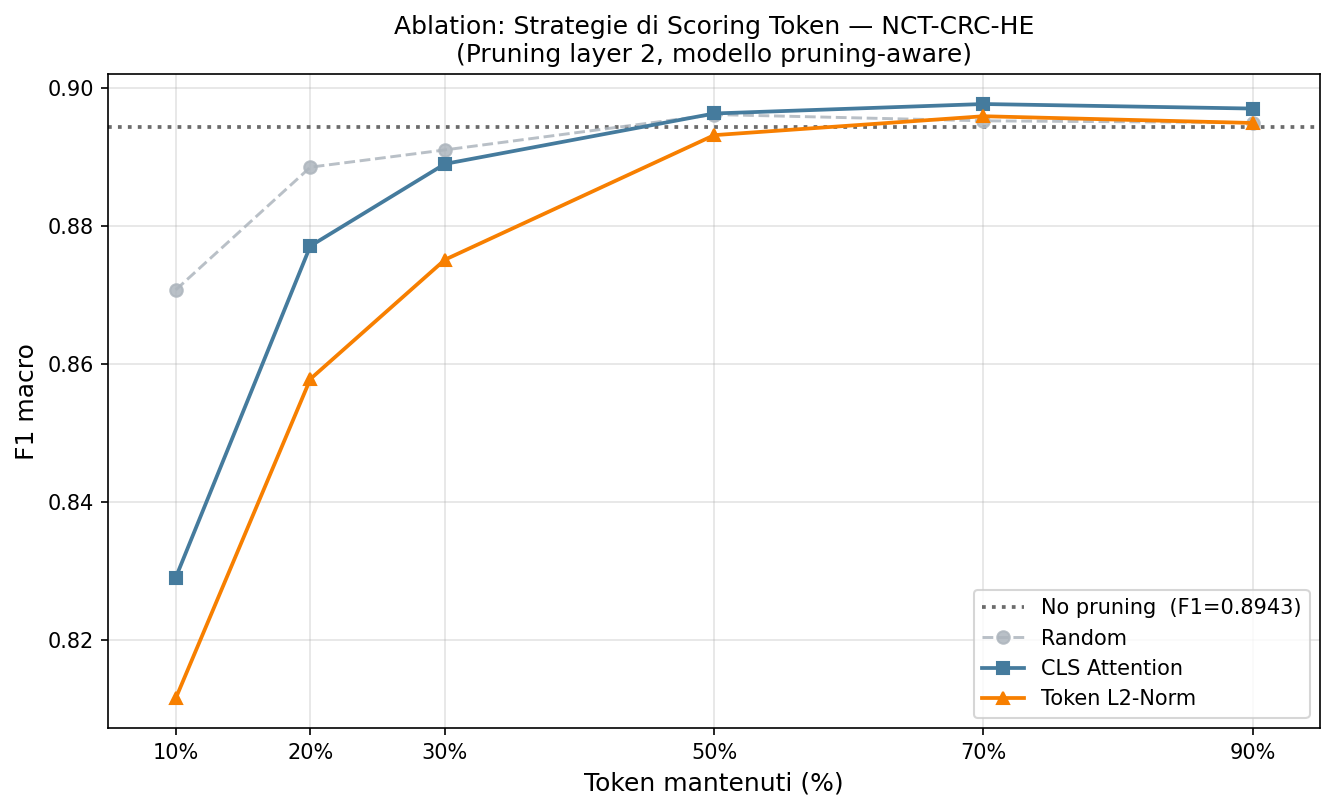

Salvato: results/NCT-CRC-HE/speed_comparison/scoring_ablation_f1.png


/tmp/ipykernel_322023/3448908323.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = float(_np_plt.trapz(f1s, krs) / (krs[-1] - krs[0]))


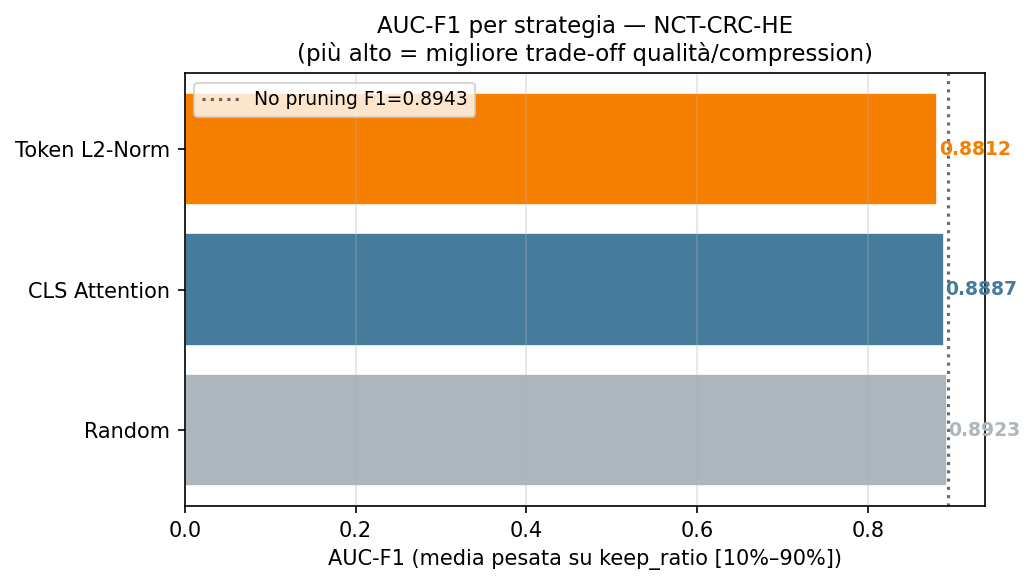

Salvato: results/NCT-CRC-HE/speed_comparison/scoring_ablation_auc.png

── Tabella riassuntiva (AUC-F1) ──
     strategy  auc_f1
       Random  0.8923
CLS Attention  0.8887
Token L2-Norm  0.8812

── F1 per keep_ratio (pivot) ──
strategy  CLS Attention  Random  Token L2-Norm
10%              0.8290  0.8707         0.8116
20%              0.8771  0.8885         0.8578
30%              0.8890  0.8910         0.8751
50%              0.8963  0.8961         0.8931
70%              0.8977  0.8952         0.8959
90%              0.8970  0.8950         0.8949


In [9]:
import numpy as _np_plt
from scipy import integrate as _sc_integrate

# ── Colori per strategia ──────────────────────────────────────────────────
STRATEGY_COLORS = {
    "Random":            "#adb5bd",
    "CLS Attention":     "#457b9d",
    "Token L2-Norm":     "#f77f00",
    "Gradient Saliency": "#d62828",
    "Forecaster":        "#e63946",
}
STRATEGY_STYLES = {
    "Random":            dict(ls="--",  lw=1.4, marker="o",  ms=6, alpha=0.85),
    "CLS Attention":     dict(ls="-",   lw=1.8, marker="s",  ms=6),
    "Token L2-Norm":     dict(ls="-",   lw=1.8, marker="^",  ms=6),
    "Gradient Saliency": dict(ls="-",   lw=1.8, marker="D",  ms=6),
    "Forecaster":        dict(ls="-",   lw=2.5, marker="*",  ms=9),
}

df_sc = _pd_sc.DataFrame(scoring_records)
strategies = [s[0] for s in SCORING_STRATEGIES]

# ─────────────────────────────────────────────────────────────────────────
# Figura 1: F1 macro vs Keep Ratio (curva principale)
# ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.axhline(f1_no_prune, color="#2d2d2d", ls=":", lw=1.8, alpha=0.7,
           label=f"No pruning  (F1={f1_no_prune:.4f})")

for strat in strategies:
    grp = df_sc[df_sc["strategy"] == strat].sort_values("keep_ratio")
    krs = grp["keep_ratio"].values
    f1s = grp["f1_macro"].values
    c   = STRATEGY_COLORS[strat]
    sty = STRATEGY_STYLES[strat]
    ax.plot(krs * 100, f1s, color=c, label=strat, **sty)

ax.set_xlabel("Token mantenuti (%)", fontsize=12)
ax.set_ylabel("F1 macro", fontsize=12)
ax.set_title(f"Ablation: Strategie di Scoring Token — {DATASET_NAME}\n"
             f"(Pruning layer {PRUNE_LAYER}, modello pruning-aware)", fontsize=12)
ax.set_xlim(5, 95)
ax.set_xticks([int(kr * 100) for kr in SCORING_KEEP_RATIOS])
ax.set_xticklabels([f"{int(kr*100)}%" for kr in SCORING_KEEP_RATIOS])
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.35)

plt.tight_layout()
out_sc1 = CFG["results_dir"] / "scoring_ablation_f1"
plt.savefig(str(out_sc1) + ".pdf", bbox_inches="tight")
plt.savefig(str(out_sc1) + ".png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_sc1}.png")

# ─────────────────────────────────────────────────────────────────────────
# Figura 2: Area Under the Curve (AUC-F1) per riassumere in un numero
# Misura la qualità complessiva del selector su tutto il range di keep_ratio.
# Un AUC più alto = migliore trade-off qualità/compression.
# ─────────────────────────────────────────────────────────────────────────
auc_rows = []
for strat in strategies:
    grp = df_sc[df_sc["strategy"] == strat].sort_values("keep_ratio")
    krs = grp["keep_ratio"].values
    f1s = grp["f1_macro"].values
    # AUC con trapezi (normalizzato per range [0.1, 0.9])
    auc_val = float(_np_plt.trapz(f1s, krs) / (krs[-1] - krs[0]))
    auc_rows.append({"strategy": strat, "auc_f1": auc_val})

df_auc = _pd_sc.DataFrame(auc_rows).sort_values("auc_f1", ascending=False)

fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
bars = ax2.barh(
    df_auc["strategy"], df_auc["auc_f1"],
    color=[STRATEGY_COLORS[s] for s in df_auc["strategy"]],
    edgecolor="white", linewidth=0.8,
)
ax2.axvline(f1_no_prune, color="#2d2d2d", ls=":", lw=1.5, alpha=0.7,
            label=f"No pruning F1={f1_no_prune:.4f}")
for bar, row in zip(bars, df_auc.itertuples()):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{row.auc_f1:.4f}", va="center", fontsize=9,
             color=STRATEGY_COLORS[row.strategy], fontweight="bold")
ax2.set_xlabel("AUC-F1 (media pesata su keep_ratio [10%–90%])", fontsize=10)
ax2.set_title(f"AUC-F1 per strategia — {DATASET_NAME}\n"
              f"(più alto = migliore trade-off qualità/compression)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="x", alpha=0.35)
plt.tight_layout()
out_sc2 = CFG["results_dir"] / "scoring_ablation_auc"
plt.savefig(str(out_sc2) + ".pdf", bbox_inches="tight")
plt.savefig(str(out_sc2) + ".png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_sc2}.png")

# ── Tabella riassuntiva ────────────────────────────────────────────────────
print("\n── Tabella riassuntiva (AUC-F1) ──")
print(df_auc.to_string(index=False, float_format="{:.4f}".format))

print("\n── F1 per keep_ratio (pivot) ──")
pivot = df_sc.pivot_table(index="keep_ratio", columns="strategy",
                           values="f1_macro", aggfunc="first")
pivot.index = [f"{int(kr*100)}%" for kr in pivot.index]
print(pivot.to_string(float_format="{:.4f}".format))

## 13 · Tabella risultati (Throughput)

In [10]:
df = pd.DataFrame(all_records)

# Formattazione display
display_cols = ["method", "variant", "throughput", "throughput_std",
                "latency_ms", "latency_std", "speedup",
                "f1_macro", "tar_at_far", "gflops"]
df_disp = df[display_cols].copy()
df_disp["throughput"] = df_disp["throughput"].map(lambda x: f"{x:.0f}")
df_disp["throughput_std"] = df_disp["throughput_std"].map(lambda x: f"±{x:.0f}")
df_disp["latency_ms"] = df_disp["latency_ms"].map(lambda x: f"{x:.2f}")
df_disp["latency_std"] = df_disp["latency_std"].map(lambda x: f"±{x:.2f}")
df_disp["speedup"] = df_disp["speedup"].map(lambda x: f"{x:.2f}×")
df_disp["f1_macro"] = df_disp["f1_macro"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
df_disp["tar_at_far"] = df_disp["tar_at_far"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
df_disp["gflops"] = df_disp["gflops"].map(lambda x: f"{x:.1f}" if pd.notna(x) and x else "—")

df_disp.columns = ["Metodo", "Variante",
                   "Throughput (img/s)", "±",
                   "Latenza (ms)", "±",
                   "Speedup", "F1 macro", "TAR@FAR", "GFLOPs"]
display(df_disp.to_string(index=False))

# Salva CSV
csv_path = CFG["results_dir"] / "speed_comparison.csv"
df.to_csv(csv_path, index=False)
print(f"\nRisultati salvati in {csv_path}")

NameError: name 'all_records' is not defined

## 14 · Grafici (Throughput)

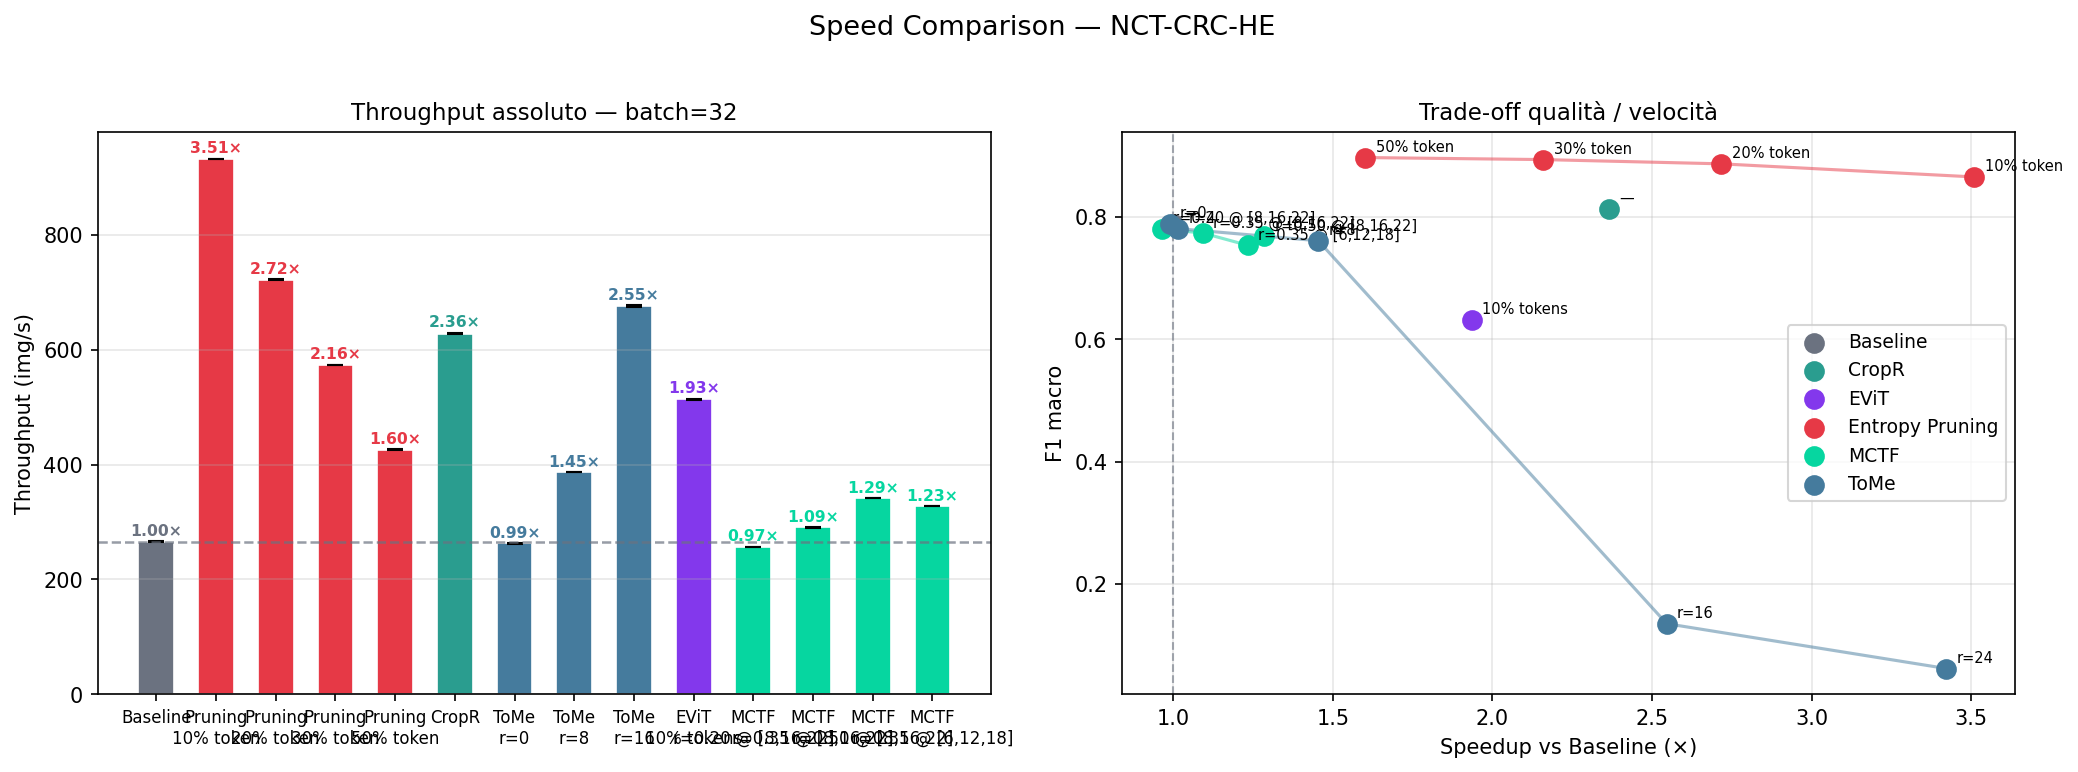

Plot salvato in results/NCT-CRC-HE/speed_comparison/speed_comparison.png / .pdf


In [ ]:
# ── Palette coerente con i metodi
METHOD_COLORS = {
    "Baseline":        "#6b7280",
    "Entropy Pruning": "#e63946",
    "CropR":           "#2a9d8f",
    "ToMe":            "#457b9d",
    "DynamicViT":      "#f4a261",
    "EViT":            "#8338ec",
    "MCTF":            "#06d6a0",
}

# ── Figura 1: Throughput assoluto (img/s) per ogni configurazione
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Seleziona i record da mostrare nel bar chart:
#   Baseline, ogni keep_ratio Entropy Pruning, CropR, ToMe r in [0,8,16], DynamicViT, EViT, MCTF
bar_rows = [
    r for r in all_records
    if r["method"] in ("Baseline", "CropR")
    or (r["method"] == "Entropy Pruning")
    or (r["method"] == "ToMe" and r["variant"] in ("r=0", "r=8", "r=16"))
    or (r["method"] == "DynamicViT")
    or (r["method"] == "EViT")
    or (r["method"] == "MCTF")
]
labels_bar = []
thrs, colors = [], []
errs = []
for r in bar_rows:
    if r["method"] == "Baseline":
        labels_bar.append("Baseline")
    elif r["method"] == "Entropy Pruning":
        labels_bar.append(f"Pruning\n{r['variant']}")
    elif r["method"] == "CropR":
        labels_bar.append("CropR")
    elif r["method"] == "DynamicViT":
        labels_bar.append(f"DynViT\n{r['variant']}")
    elif r["method"] == "EViT":
        labels_bar.append(f"EViT\n{r['variant']}")
    elif r["method"] == "MCTF":
        labels_bar.append(f"MCTF\n{r['variant']}")
    else:
        labels_bar.append(f"ToMe\n{r['variant']}")
    thrs.append(r["throughput"])
    errs.append(r["throughput_std"])
    colors.append(METHOD_COLORS[r["method"]])

ax = axes[0]
bars = ax.bar(range(len(labels_bar)), thrs, color=colors,
              width=0.6, edgecolor="white", linewidth=0.8)
ax.errorbar(range(len(labels_bar)), thrs, yerr=errs,
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.axhline(baseline_throughput, color="#6b7280", ls="--", lw=1.2, alpha=0.7,
           label="Baseline")
ax.set_xticks(range(len(labels_bar)))
ax.set_xticklabels(labels_bar, fontsize=8)
ax.set_ylabel("Throughput (img/s)", fontsize=10)
ax.set_title(f"Throughput assoluto — batch={CFG['thr_batch_size']}", fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Annota speedup sopra le barre
for i, r in enumerate(bar_rows):
    spd = r["speedup"]
    ax.text(i, thrs[i] + errs[i] + 5, f"{spd:.2f}×",
            ha="center", va="bottom", fontsize=7.5, fontweight="bold",
            color=METHOD_COLORS[r["method"]])

# ── Figura 2: F1 macro vs Speedup (scatter trade-off)
ax2 = axes[1]
for method, grp in pd.DataFrame(all_records).groupby("method"):
    if grp["f1_macro"].isna().all():
        continue
    grp = grp.dropna(subset=["f1_macro"])
    ax2.scatter(grp["speedup"], grp["f1_macro"],
                color=METHOD_COLORS.get(method, "#888"),
                label=method, s=80, zorder=3)
    if len(grp) > 1:
        grp_s = grp.sort_values("speedup")
        ax2.plot(grp_s["speedup"], grp_s["f1_macro"],
                 color=METHOD_COLORS.get(method, "#888"),
                 alpha=0.5, lw=1.5)
    for _, row in grp.iterrows():
        lbl = row["variant"]
        ax2.annotate(lbl, (row["speedup"], row["f1_macro"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=7)

ax2.axvline(1.0, color="#6b7280", ls="--", lw=1, alpha=0.6)
ax2.set_xlabel("Speedup vs Baseline (×)", fontsize=10)
ax2.set_ylabel("F1 macro", fontsize=10)
ax2.set_title("Trade-off qualità / velocità", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f"Speed Comparison — {DATASET_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
out = CFG["results_dir"] / "speed_comparison"
plt.savefig(str(out) + ".pdf", bbox_inches="tight")
plt.savefig(str(out) + ".png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot salvato in {out}.png / .pdf")

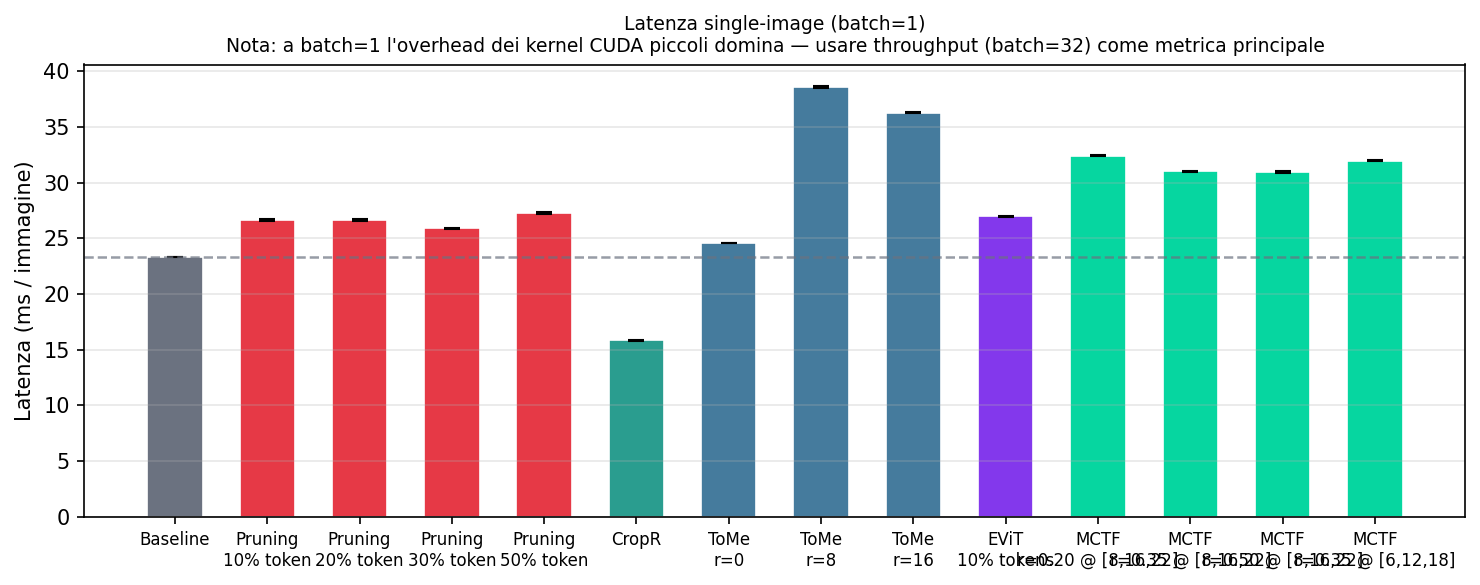

In [ ]:
# ── Figura 3: confronto latenza (ms/img, batch=1) — mostra perché batch=1 è ingannevole
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

lats, lbls_lat, colors_lat, errs_lat = [], [], [], []
for r in bar_rows:
    lats.append(r["latency_ms"])
    errs_lat.append(r["latency_std"])
    colors_lat.append(METHOD_COLORS[r["method"]])
    lbls_lat.append(labels_bar[bar_rows.index(r)])

ax.bar(range(len(lbls_lat)), lats, color=colors_lat,
       width=0.6, edgecolor="white", linewidth=0.8)
ax.errorbar(range(len(lbls_lat)), lats, yerr=errs_lat,
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.axhline(all_records[0]["latency_ms"], color="#6b7280",
           ls="--", lw=1.2, alpha=0.7, label="Baseline")
ax.set_xticks(range(len(lbls_lat)))
ax.set_xticklabels(lbls_lat, fontsize=8)
ax.set_ylabel("Latenza (ms / immagine)", fontsize=10)
ax.set_title(
    f"Latenza single-image (batch=1)\n"
    f"Nota: a batch=1 l'overhead dei kernel CUDA piccoli domina — "
    f"usare throughput (batch={CFG['thr_batch_size']}) come metrica principale",
    fontsize=9,
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out_lat = CFG["results_dir"] / "latency_comparison"
plt.savefig(str(out_lat) + ".png", dpi=300, bbox_inches="tight")
plt.show()

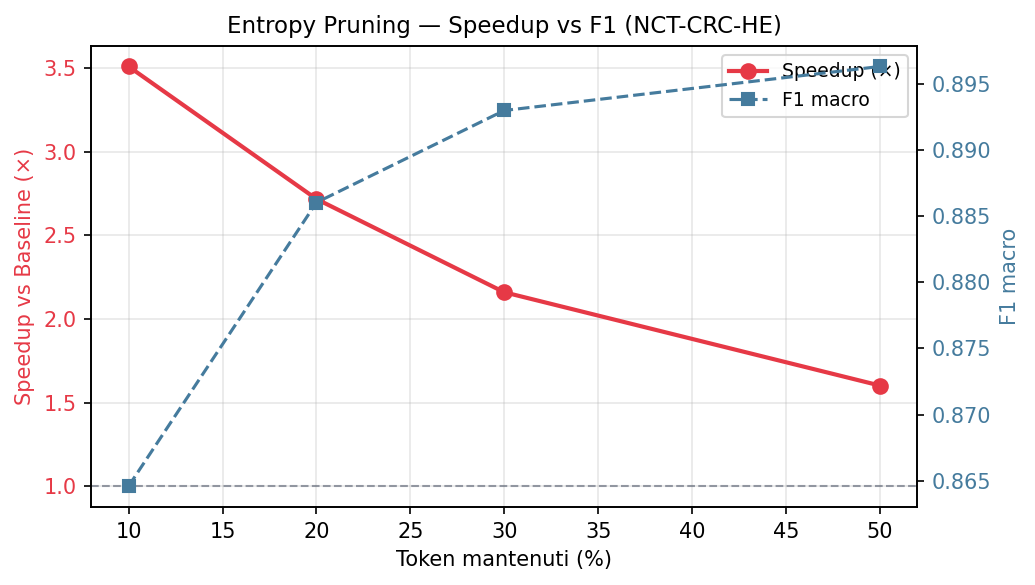

In [ ]:
# ── Figura 4: Entropy Pruning sweep — speedup e F1 al variare di keep_ratio
if pruning_records:
    df_p = pd.DataFrame(pruning_records).sort_values("keep_ratio")

    fig, ax1 = plt.subplots(figsize=(7, 4), dpi=150)
    ax2_r = ax1.twinx()

    krs = [int(r * 100) for r in df_p["keep_ratio"]]
    ax1.plot(krs, df_p["speedup"], "o-", color="#e63946", lw=2, label="Speedup (×)", ms=7)
    ax1.axhline(1.0, color="#6b7280", ls="--", lw=1, alpha=0.7)
    ax1.set_xlabel("Token mantenuti (%)", fontsize=10)
    ax1.set_ylabel("Speedup vs Baseline (×)", color="#e63946", fontsize=10)
    ax1.tick_params(axis="y", labelcolor="#e63946")

    ax2_r.plot(krs, df_p["f1_macro"], "s--", color="#457b9d", lw=1.5, label="F1 macro", ms=6)
    ax2_r.set_ylabel("F1 macro", color="#457b9d", fontsize=10)
    ax2_r.tick_params(axis="y", labelcolor="#457b9d")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2_r.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    ax1.set_title(f"Entropy Pruning — Speedup vs F1 ({DATASET_NAME})", fontsize=11)
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    out_sw = CFG["results_dir"] / "entropy_pruning_sweep"
    plt.savefig(str(out_sw) + ".png", dpi=300, bbox_inches="tight")
    plt.show()